# Решение линейного стока (с использованием Ei)

Материалы курсов "Исследования скважин и пластов" и "Гидродинамические исследования скважин" в РГУ нефти и газа имени И.М.Губкина.

Версия 0.4 от 27.10.2025


---

Содержание

1. [Уравнение фильтрации в радиальной форме ](#321)
2. [Решение линейного стока](#322)
3. [Построение графика решения от расстояния для произвольного момента времени в безразмерных координатах](#323)
4. [Построение графика решения - изменения забойного давления от времени в безразмерных координатах](#324)
5. [Построение графиков решения в размерных координатах](#325)
6. [Построение графиков для разных моментов времени](#326)
7. [Задания для самостоятельной работы](#327)

In [8]:
# импортируем библиотеки для расчетов

# numpy используем для работы с массивами и подготовки данных для построения графиков. 
# Также в некоторых функциях используем возможности векторных расчетов numpy
import numpy as np
# matplotlib используем для построения графиков
import matplotlib.pyplot as plt
# scipy.special используем как альтернативный вариант расчета специальных функций
import scipy.special as sp


# 1. Уравнение фильтрации в радиальной форме <a class="anchor" id="321"></a>

## Уравнение фильтрации, единицы измерения СИ
Уравнение фильтрации для радиального потока в линеаризованном виде можно записать в виде


$$
\frac{\partial^2p}{\partial t^2} + \frac{1}{r}\frac{\partial p}{\partial r} = \frac{1}{\kappa}\frac{\partial p}{\partial t}
$$
где 
- $p(r,t)$ - давление в пласте, Па
- $r$ - расстояние, м
- $t$ - время, сек
- $\kappa$ -  коэффициент пьезопроводности 

$$
\kappa = \frac{k}{\varphi \mu\ c_t}
$$

Для построения решения надо задать начальное и граничные условия. Зададим условия для бесконечно малого радиуса скважины и бесконечного пласта. 

Начальное условие. До запуска скважины в момент времени  $t = 0$ давление в пласте равно начальному во всех точках $p=p_i$
$$ 
p(r,t) =  p_i , {t\le0}
$$

* условие постоянства дебита на скважине - граничное условие на скважине
$$ 
\lim_{r \to 0} { \frac{2\pi kh}{\mu B} \left( r \frac{\partial p}{\partial r} \right) } = -q  
$$

* условие на бесконечном расстоянии возмущения от скважине нет
$$ 
\lim_{r \to \infty}{ p(r,t)} =  p_i
$$

## Уравнение фильтрации, практические метрические единицы изменения
То же уравнение можно записать используя практические метрические единицы измерения
$$ 
\frac{\partial^2p}{\partial t^2} + \frac{1}{r}\frac{\partial p}{\partial r} = \frac{\varphi \mu c_t}{0.00036 k} \frac{\partial p}{\partial t} 
$$

Напомним, здесь
* $p(r,t)$ - давление в пласте, атм
* $t$ - время, час
* $k$ - проницаемость в направлении движения потока, мД
* $\mu$ - динамическая вязкость, сП
* $\phi$ - пористость, д.е.
* $c_t$ - сжимаемость, 1/атм
* $r$ - расстояние от центра, м


Начальное условие. До запуска скважины в момент времени  $t = 0$ давление в пласте равно начальному во всех точках $p=p_i$
$$ 
p(r,t) =  p_i , {t\le0}
$$

* условие постоянства дебита на скважине - граничное условие на скважине
$$ 
\lim_{r \to 0} { \frac{ kh}{ 18.42 \mu B} \left( r \frac{\partial p}{\partial r} \right) } = -q  
$$

* условие на бесконечном расстоянии возмущения от скважине нет
$$ 
\lim_{r \to \infty}{ p(r,t)} =  p_i
$$


## Уравнение фильтрации, безразмерные переменные
Часто для анализа уравнений неустановившейся фильтрации используются безразмерные переменные. Мы будем использовать переменные в виде:

$$ r_D = \frac{r}{r_w} \tag{2} $$
$$ t_D = \frac{0.00036 kt}{\phi \mu c_t r_w^2}  \tag{3}$$
$$ p_D = \frac{kh}{ 18.42 q_s B \mu} \left( p_i - p \right)  \tag{4} $$
$$ q_D = \frac{q}{ q_{ref} }$$


где в свою очередь 
* $q$ - дебит скважины на поверхности, приведенный к нормальным условиям, м^3^/сут
* $q_{ref}$ - референсный дебит скважины на поверхности, приведенный к нормальным условиям, м^3^/сут
* $\phi$ - пористость, доли единиц
* $\mu$ - вязкость нефти в пласте, сП
* $B$ - объемный коэффициент нефти, м^3^/м^3^
* $p_i$ - начальное давление в пласте, атм
* $p$ - давление забойное, атм
* $c_t$ - общая сжимаемость системы в пласте, 1/атм
* $k$ - проницаемость, мД
* $t$ -  время, час
* $r$ - расстояние от центра скважины, м
* $r_w$ - радиус скважины, м

Использование безразмерных переменных позволяет упростить уравнение фильтрации , которое примет вид

$$ 
\frac{\partial p_D}{ \partial t_D} = \dfrac{1}{r_D} \left[ \dfrac{\partial}{\partial r_D} \left( r_D \dfrac{ \partial p_D} {\partial r_D} \right) \right] 
\tag{5}
$$

Решение этого уравнения - функция безразмерного давления от безразмерных времени и расстояния $p_D(r_D, t_D) $


* начальное условие. До запуска скважины в момент времени  $t_D = 0$ давление в пласте равно начальному во всех точках $p=p_i$
$$ 
t_D < 0, p_D = 0
$$

* условие постоянства дебита на скважине - граничное условие на скважине
$$ 
\lim_{r_D \to 0} { r_D \frac{\partial p_D}{\partial r_D}} = q_D  
$$

* условие на бесконечном расстоянии возмущения от скважине нет
$$ 
r_D = \infty, p_D = 0  
$$

In [9]:
# определим безразмерные переменные

# определим функции для перевода размерных переменных в безразмерные и обратно
# пригодится потом для построения графиков и ведения расчетов

# при наименовании функций придерживаемся следующих соглашений
# сначала идет название того, что считаем
# в конце указывается размерность результата, если это уместно



def q_from_qd_sm3day(qd, q_ref_sm3day=1):
    """
    перевод безразмерного дебита скважины в размерный
    qd - безразмерный дебит скважины
    q_ref_sm3day - референсный дебит
    """
    return  qd * q_ref_sm3day 

def qd_from_q(q_sm3day, q_ref_sm3day=1):
    """
    перевод размерного дебита в безразмерные
    q_sm3day -  дебит скважины, ст. м3/сут
    q_ref_sm3day - референсный дебит
    """
    return q_sm3day / q_ref_sm3day

def r_from_rd_m(rd, rw_m=0.1):
    """
    перевод безразмерного расстояния в размерное
    rd -  безразмерное расстояние
    rw_m -  радиус скважины, м
    """
    return rd*rw_m

def rd_from_r(r_m, rw_m=0.1):
    """
    перевод размерного расстояния в безразмерное
    r_m - размерное расстояние, м
    rw_m - радиус скважины, м
    """
    return r_m/rw_m

def t_from_td_hr(td, k_mD=10, phi=0.2, mu_cP=1, ct_1atm=1e-5, rw_m=0.1):
    """
    перевод безразмерного времени в размерное, результат в часах
    td - безразмерное время
    k_mD - проницаемость пласта, мД
    phi - пористость, доли единиц
    mu_cP - динамическая вязкость флюида, сП
    ct_1atm - общая сжимаемость, 1/атм
    rw_m - радиус скважины, м
    """
    return td * phi * mu_cP * ct_1atm * rw_m * rw_m / k_mD / 0.00036

def td_from_t(t_hr, k_mD=10, phi=0.2, mu_cP=1, ct_1atm=1e-5, rw_m=0.1):
    """
    перевод размерного времени в безразмерное
    t_hr - размерное время, час
    k_mD - проницаемость пласта, мД
    phi - пористость, доли единиц
    mu_cP - динамическая вязкость флюида, сП
    ct_1atm - общая сжимаемость, 1/атм
    rw_m - радиус скважины, м
    """
    return  0.00036 * t_hr * k_mD / (phi * mu_cP * ct_1atm * rw_m * rw_m)

def p_from_pd_atma(pd, k_mD=10, h_m=10, q_ref_sm3day=1, b_m3m3=1.2, mu_cP=1, pi_atma=250):
    """
    перевод безразмерного давления в размерное, результат в абсолютных атмосферах
    pd - безразмерное давление
    k_mD - проницаемость пласта, мД
    h_m - мощность пласта, м
    q_ref_sm3day - дебит на поверхности, м3/сут в с.у.
    fvf_m3m3 - объемный коэффициент нефти, м3/м3
    mu_cP - динамическая вязкость флюида, сП
    pi_atma - начальное давление, абсолютные атм.
    """
    return pi_atma - pd * 18.42 * q_ref_sm3day * b_m3m3 * mu_cP / k_mD / h_m

def pd_from_p(p_atma, k_mD=10, h_m=10, q_ref_sm3day=1, b_m3m3=1.2, mu_cP=1, pi_atma=250):
    """
    перевод размерного давления в безразмерное
    p_atma - давление
    k_mD - проницаемость пласта, мД
    h_m - мощность пласта, м
    q_ref_sm3day - дебит на поверхности, м3/сут в с.у.
    fvf_m3m3 - объемный коэффициент нефти, м3/м3
    mu_cP - динамическая вязкость флюида, сП
    pi_atma - начальное давление, абсолютные атм.
    """
    return (pi_atma - p_atma) / (18.42 * q_ref_sm3day * b_m3m3 * mu_cP) * k_mD * h_m


# 2. Решение линейного стока 
Для решения уравнения фильтрации - линейного дифференциального уравнения в частных производных второго порядка необходимо задать начальные и граничные условия.
Самое простое решение можно получить для случая вертикальной скважины бесконечно малого радиуса запускающейся с постоянным дебитом. Условия соответствующие этому случаю можно выразить следующим образом


В этом случае решение может быть выражено через функцию интегральной экспоненты
$$ 
p_D(r_D,t_D) = - \frac{q_D}{2 } Ei \left(- \dfrac{ r_D^2}{4t_d} \right)  \tag{9}
$$

где -Ei(-x) - интегральная показательная функция.

Решение в размерных переменных можно записать как
$$
p\left(r,t\right)=p_i-\frac{18.42q_sB\mu}{kh}\left(-\frac{1}{2} Ei \left(-\frac{\varphi\mu c_tr^2}{0.00144kt}\right)\right) 
\tag{10}
$$



## Учет скин-фактора для решения линейного стока
Можно добавить скин-фактор

Получим в безразмерном виде решение для забойного давления с учетом скин-фактора

для положительного скин-фактора $S$
$$ 
p_D(r_D, t_D, q_D) = \begin{cases} 
     - \dfrac{q_D}{2 }  Ei \left(- \dfrac{ r_D ^2}{4t_d} \right)    & \text{если }  r_D > 1 \\[10pt]
     - \dfrac{q_D}{2 } \left[  Ei \left(- \dfrac{ 1}{4t_d} \right) + 2S \right]    & \text{если }  r_D = 1 
     \end{cases}
$$

для отрицательного скин-фактора $S$
$$ 
p_D(r_D, t_D, q_D) = \begin{cases} 
     - \dfrac{q_D}{2 }  Ei \left(- \dfrac{ r_D ^2}{4t_d} \right)    & \text{если } S<0  \text{ и } r_D > e^{-S} \\[10pt]
     - \dfrac{q_D}{2 }   Ei \left(- \dfrac{ {e^{-S}}^2}{4t_d} \right)    & \text{если } S<0  \text{ и } r_D \le e^{-S} 
     \end{cases}
$$

В программной реализаци расчета безразменого решения линейного стока, для обеспечения векторных расчетов с библиотекой `numpy` вместо явных условных переходов можно использовать функцию Хевисайда.

In [10]:
# Решение линейного стока уравнения фильтрации
def pd_line_source_ei(td, rd, qd=1, skin=0):
    """
    Решение линейного стока уравнения фильтрации
    rd - безразмерное расстояние
    td - безразмерное время
    qd - безразмерный дебит
    skin - величина скин-фактора
    """
    # оценим приведенный радиус скважины
    rd_eff = np.exp(-skin) * np.heaviside(-skin, 0) + np.heaviside(skin, 1)
    # преобразуем входные радиусы в приведенные с учетом величины скин-фактора
    rd_calc = rd * np.heaviside(rd - rd_eff, 0) + np.exp(-skin) * np.heaviside(rd_eff - rd, 1)
    # исключим нулевые величины времени, чтобы избежать деления на ноль
    #td_safe = td * np.heaviside(td, 1)
    td_safe = np.where(td > 0, td, 1)
    pd = - qd / 2 / np.pi * ( 1 / 2  * sp.expi(-rd_calc**2 / 4 / td_safe)  )
    # в конце обнулим результаты для нулевых моментов времени
    return  pd * np.heaviside(td, 0)

In [11]:
pd_line_source_ei(0,1)

np.float64(0.0)

# 3. Построение графика решения от расстояния для произвольного момента времени в безразмерных координатах <a class="anchor" id="323"></a>

Пример показывает как построить распределение давления для заданного момента времени. Помните что тут безразмерное давление и время. Для построения графика используется логарифмическое распределение значений расстояния, так как около нуля требуется больше точек для отображения из за значительного изменения функции.

скин-фактор = -3


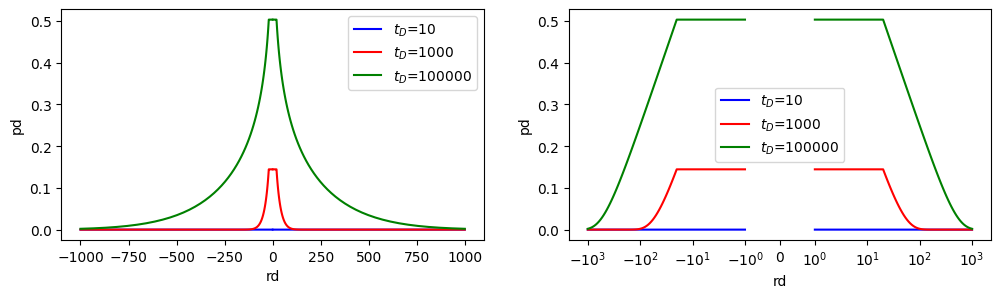

скин-фактор = 0


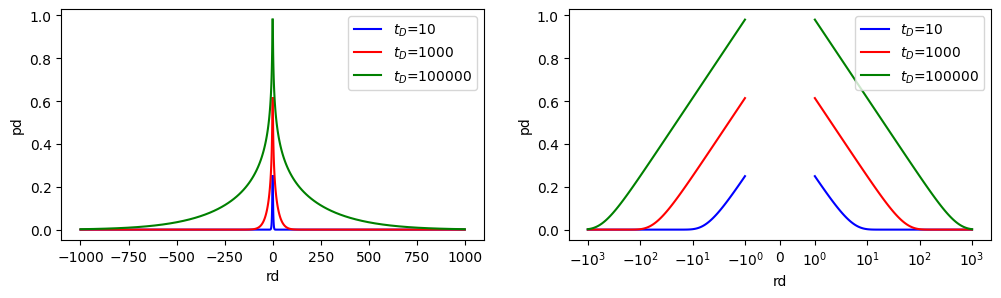

скин-фактор = 3


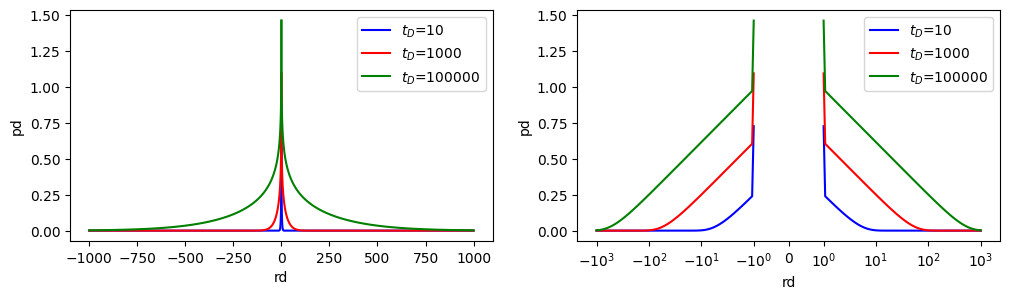

In [12]:
rd_arr = np.logspace(0, 3, 100)
clr = ['b', 'r', 'g']
for skin in [-3,0,3]:
    print(f'скин-фактор = {skin}')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))
    i = 0
    for td in [10, 1000, 100000]:
        # при построении используем векторный расчет
        ax1.plot(rd_arr, pd_line_source_ei(td, rd_arr, skin = skin), clr[i], label = f'$t_D$={td}' )
        ax1.plot(-rd_arr, pd_line_source_ei(td, rd_arr, skin = skin), clr[i])
        ax2.plot(rd_arr, pd_line_source_ei(td, rd_arr, skin = skin), clr[i], label = f'$t_D$={td}' )
        ax2.plot(-rd_arr, pd_line_source_ei(td, rd_arr, skin = skin), clr[i] )
        i = i + 1
    #plt.title("Решение уравнения линейного стока для td = {}".format(td))
    ax1.set_xlabel("rd")
    ax1.set_ylabel("pd")
    ax2.set_xlabel("rd")
    ax2.set_ylabel("pd")
    ax1.legend()
    ax2.legend()
    ax2.set_xscale('symlog', linthresh=1, linscale=0.6)
    plt.show()

Зависимость безразмерного забойного давления от времени

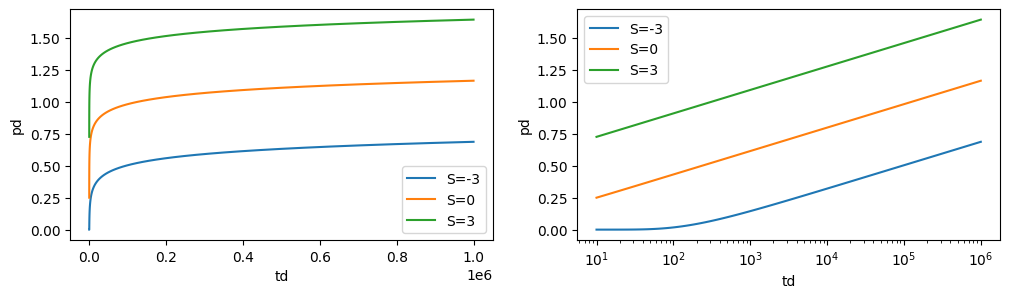

In [13]:
td_arr = np.logspace(1, 6, 100)
rd = 1
# при построении используем векторный расчет
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))
for skin in [-3,0,3]:
    ax1.plot(td_arr, pd_line_source_ei(td_arr, rd, skin = skin), label = f'S={skin}' )
    ax2.plot(td_arr, pd_line_source_ei(td_arr, rd, skin = skin), label = f'S={skin}' )
#plt.title("Решение уравнения линейного стока для td = {}".format(td))
ax1.set_xlabel("td")
ax1.set_ylabel("pd")
ax2.set_xlabel("td")
ax2.set_ylabel("pd")
ax2.set_xscale('log')
ax1.legend()
ax2.legend()
plt.show()

# 2. Расчет кривой восстановления давления <a class="anchor" id="342"></a>

Один из самых простых примеров применения суперпозиции. Предполагаем, что добывающая скважина в однородном изотропном пласте запускается в момент времени `t=0` и работает `t_p_hr` часов, после чего останавливается. После остановки скважины забойное давление растет - и мы получим кривую восстановления давления.

Пусть решение задачи запуска скважины (падения давления) будет $P_D(t_D, r_D)$. Тогда решение для изменения давления при запуске и последующей остановки скважины можно представить в виде 
$$P_{bu.D}(t_D, t_{prod.D}, r_D) = P_D(t_D) - P_D(t_D-t_{prod.D}, r_D) \cdot \mathcal{H}(t_D-t_{prod.D})  \tag{14.1}$$

где
* $t_D$ - безразмерное время после запуска скважины,
* $t_{prod.D}$ - безразмерное время работы скважины после запуска
* $\mathcal{H}$ - ступенчатая [функция Хевисайда](https://ru.wikipedia.org/wiki/%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F_%D0%A5%D0%B5%D0%B2%D0%B8%D1%81%D0%B0%D0%B9%D0%B4%D0%B0) (в некоторых книгах обозначается как $\theta$)
* $P_D(t_D, r_D)$ - безразмерное давление - решение задачи запуска скважины (падения давления)
* $P_{bu.D}(t_D, t_{prod.D}, r_D)$ - безразмерное давление- решение задачи запуска скважины и последующей остановки скважины

Для проведения векторных расчетов в python удобно выражение с использованием функции Хевисайда

$$ \mathcal{H} = \begin{cases}0 & x < 0\\1 & x = 0\\1 & x > 0\end{cases}$$

Применение функции Хевисайда позволяет избежать в расчетных функциях применение условных операторов в явном виде для отдельных элементов входных массивов. Это потенциально ускоряет расчет. 

In [14]:
def pd_line_source_ei_build_up(td, td_p, rd):
    """
    расчет давления для запуска и последующей остановки скважины
    td - время после запуска
    td_p - время безразмерное - которое скважина работала до остановки
    rd - расстояния от скважины
    """
    
    # применение функции Хевисайда здесь делает расчет корректным
    # для входных векторов td
    return pd_line_source_ei(td, rd) - np.heaviside(td-td_p,1) * pd_line_source_ei(td-td_p, rd)

время работы скважины 24.00 часа, что соответсвует безразмерному времени 4320000.00


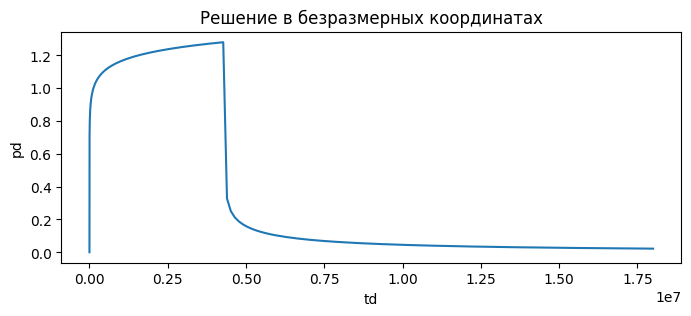

In [15]:
t_arr = np.logspace(-10, 2, 1000)
t_prod_hr = 24
k = 10   # проницаемость
q = 30   # дебит

# переведем размерный массив времени в безразмерные величины
# некоторые параметры можно было бы пропустить и оставить значения по умолчанию
# но для полноты приведем их в явном виде

td_arr = td_from_t(t_arr, k_mD=k, phi=0.2, mu_cP=1, ct_1atm=1e-05, rw_m=0.1)
td_prod = td_from_t(t_prod_hr, k_mD=k, phi=0.2, mu_cP=1, ct_1atm=1e-05, rw_m=0.1)

print('время работы скважины {:.2f} часа, что соответсвует безразмерному времени {:.2f}'.format(t_prod_hr, td_prod))

# для заданного массива безразмерных времен рассчитаем безразмерные давления
pd_arr = pd_line_source_ei_build_up(td_arr, td_prod, rd=1)

# построение графика
plt.rcParams["figure.figsize"] = (8,3)

plt.plot(td_arr, pd_arr)

plt.xlabel('td')
plt.ylabel('pd')
plt.title('Решение в безразмерных координатах')
plt.show()

In [16]:
pd_line_source_ei(0,1)

np.float64(0.0)